In [ ]:
import numpy as np

# ФИЗИЧЕСКИЕ КОНСТАНТЫ МОДЕЛИ

rho = 1.225          # плотность воздуха, кг/м³
R = 50.0             # радиус ротора, м
A = np.pi * R**2     # площадь ротора, м^2
P_rated = 5000000    # номинальная мощность, Вт (поставила как в пдф документации к NREL 5-MW )
v_rated = 12.0       # номинальная скорость ветра, м/с
Cp_max = 16/27       # предел Беца

# РАСПРЕДЕЛЕНИЕ ВЕТРА Weibull(k, c)

weibull_k = 2.0      # параметр формы
weibull_c = 8.0      # параметр масштаба, м/с
n_samples = 1000     # число сэмплов Монте-Карло на одну оценку J(θ)

# ОГРАНИЧЕНИЯ НА РЕЖИМ РАБОТЫ

v_cut_in  = 3.0      # скорость включения турбины, м/с
v_cut_out = 25.0     # скорость отключения турбины, м/с

beta_min  = 0.0      # минимальный угол лопастей, градусы
beta_max  = 30.0     # максимальный угол лопастей, градусы

omega_min = 0.0      # минимальная угловая скорость, рад/с
omega_max = 2.0      # максимальная угловая скорость, рад/с

# ПАРАМЕТРЫ ОПТИМИЗАЦИИ θ = (a0, a1, a2, b0, b1)
# Закон управления углом:    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
# Закон управления скоростью: ω(v) = b0 + b1*v

# Границы поиска для каждого параметра [min, max]
bounds = np.array([
    [0.0,  30.0],   # a0 — базовый угол лопастей, градусы
    [-5.0,  5.0],   # a1 — линейный коэффициент β(v)
    [-1.0,  1.0],   # a2 — квадратичный коэффициент β(v)
    [0.0,   2.0],   # b0 — базовая угловая скорость, рад/с
    [0.0,   0.2],   # b1 — линейный коэффициент ω(v)
])

n_dims = len(bounds)  # размерность задачи = 5

# КОЭФФИЦИЕНТЫ ШТРАФНОЙ ФУНКЦИИ
# J(θ) = -E[P(v;θ)] + alpha*Var(P) + gamma*E[max(0, P-P_rated)^2] + delta*Penalty_bounds(θ)

alpha = 0.05   # штраф за нестабильность мощности (дисперсию)
gamma = 10.0   # штраф за превышение номинальной мощности
delta = 10.0   # штраф за выход параметров за допустимые границы

Предлагаю турбину NREL 5-MW
Документация https://docs.nrel.gov/docs/fy09osti/38060.pdf
стр.2

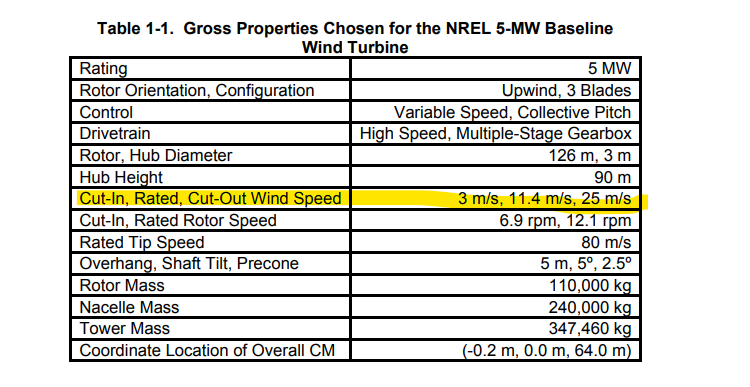

v_cut_in = 3.0 и v_cut_out = 25.0 — взяты из общепринятых инженерных норм для ветротурбин класса 5 МВт. Это стандартные значения, взятые из источника "Definition of a 5-MW Reference Wind Turbine for Offshore System Development" по ветроэнергетике.

Границы bounds:

a0: [0, 30] — прямо следует из постановки: beta_min = 0, beta_max = 30, базовый угол не может выходить за физические пределы лопасти.

a1: [-5, 5] и a2: [-1, 1] — взяты эвристически. В постановке задачи ограничения на a1 и a2 явно не заданы. Логика такая: при v от 3 до 25 м/с и отклонении от v_rated = 12 до 13 м/с, коэффициент a1 = 5 даёт вклад 65° — уже за пределами beta_max. Но это именно эвристика, не вывод из постановки.

b0: [0, 2] — следует из [omega_min, omega_max], базовая скорость не может выходить за механические пределы.

b1: [0, 0.2] — эвристика: при b1 = 0.2 и v = 25 получаем ω = b0 + 5.0, что при b0 > 0 превысит omega_max = 2.0. Но это мягкое ограничение — выход за него штрафуется через delta, а не запрещается жёстко.

Для корректной работы лучше убрать жёсткие bounds на a1 и a2 — сделать их шире (например [-10, 10] и [-2, 2]) и положиться на штраф delta * Penalty_bounds, который уже есть в функции цели. Либо явно обосновать выбор в описании эксперимента.

In [ ]:
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ УПРАВЛЕНИЯ

def beta_control(v, theta):
    """
    Закон управления углом лопастей.
    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
    Результат обрезается до [beta_min, beta_max].
    """
    a0, a1, a2, b0, b1 = theta
    beta = a0 + a1 * (v - v_rated) + a2 * (v - v_rated)**2
    return np.clip(beta, beta_min, beta_max)


def omega_control(v, theta):
    """
    Закон управления угловой скоростью ротора.
    ω(v) = b0 + b1*v
    Результат обрезается до [omega_min, omega_max].
    """
    a0, a1, a2, b0, b1 = theta
    omega = b0 + b1 * v
    return np.clip(omega, omega_min, omega_max)


def sample_wind(seed=None):
    """
    Сэмплирование скорости ветра из распределения Вейбулла.
    Возвращает только скорости в рабочем диапазоне [v_cut_in, v_cut_out].
    """
    rng = np.random.default_rng(seed)
    v_all = weibull_c * rng.weibull(weibull_k, size=n_samples)
    mask = (v_all >= v_cut_in) & (v_all <= v_cut_out)
    return v_all[mask] if mask.sum() > 0 else np.array([v_rated])

In [ ]:
def penalty_bounds(theta):
    """Квадратичный штраф за выход θ за bounds."""
    return float(np.sum(np.maximum(0.0, lo - theta)**2
                      + np.maximum(0.0, theta - hi)**2))

In [ ]:
def compute_Cp(lam, beta):
    """
    Аппроксимация коэффициента мощности Cp(λ, β) по формуле Heier.
    Результат обрезается до [0, Cp_max].
    """
    lam = np.where(lam  < 1e-6, 1e-6, lam)
    beta = np.where(beta < 0.0,  0.0,   beta)
    inv = 1.0 / (lam + 0.08 * beta) - 0.035 / (beta**3 + 1.0)
    inv = np.where(np.abs(inv) < 1e-6, 1e-6, inv)
    Cp = (0.5176 * (116.0 * inv - 0.4 * beta - 5.0)
            * np.exp(-21.0 * inv) + 0.0068 * lam)
    return np.clip(Cp, 0.0, Cp_max)

https://www.mdpi.com/1996-1073/16/6/2774

(30) формула

In [ ]:
MC_SEED = 999  # глобальная константа, одна для всех методов и запусков

def objective(theta, mc_seed=MC_SEED):
    """
    mc_seed фиксирован → одни и те же реализации ветра при каждом вызове.
    algo_rng больше не попадает сюда.
    """
    v = sample_wind(seed=mc_seed)
    beta  = beta_control(v, theta)
    omega = omega_control(v, theta)
    lam   = omega * R / v
    Cp    = compute_Cp(lam, beta)
    p     = 0.5 * rho * A * Cp * v**3 / P_rated

    return (-np.mean(p)
            + alpha * np.var(p)
            + gamma * np.mean(np.maximum(0.0, p - 1.0)**2)
            + delta  * penalty_bounds(theta))